# 03 — Results evaluation

Evaluates the campaign recorded in `out/results/{runs,traces}.csv`. Every figure is exported to
`out/results/figures/` as paper-ready PDF (+ PNG preview).

## Evaluation protocol

- **Canonical objective** `J` (lower is better): every value was re-computed by the gateway
  reference evaluator from the returned binding — engine-independent by construction.
- **Baseline**: the *random-search* engine (expected worst quality despite its speed); improvement
  percentages are expressed against it.
- **Reference per instance** (`reference_J`): the exact solver's result when available —
  `exact_optimal` (proved) or `exact_incumbent` (best anytime solution at the budget) — and, when
  the exact solver returned nothing, the best heuristic value at the **standard 1 000-evaluation
  cutoff** (`heuristic_fallback`), derived offline from the traces.
- **Stopping criterion**: a shared wall-clock budget T; traces record every best-so-far improvement
  `(eval_index, elapsed_ms)`, enabling the offline cutoff studies of §5.

## Research questions addressed (paper RQ1–RQ4)

1. **RQ1 — representation and semantic consistency**: run health, oracle audit, and feasibility
   across engines (§1, §2).
2. **RQ2 — feasibility versus optimization**: first feasible placement vs optimized binding
   (§3.6), improvement over the baseline and gaps to the reference (§3.3, §3.4).
3. **RQ3 — quality, runtime, and scalability**: objective distributions and performance profiles
   (§3.1–§3.5), runtime and completion status (§4), statistical comparison (§7).
4. **RQ4 — suitability for runtime rebinding**: stopping-criterion study (§5), in particular the
   time to reach the exact reference (§5.4), plus the convergence examples (§6).

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'docker-compose.yml').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / 'experimentation/icsoc'))

import analysis
analysis = importlib.reload(analysis)  # guard against a stale module in long-lived kernels
from analysis import BASELINE_ENGINE, ENGINE_COLORS, ENGINE_LABELS, EXACT_ENGINE

RESULTS = REPO_ROOT / 'experimentation/icsoc/out/results'
FIGURES = RESULTS / 'figures'

runs, traces = analysis.load_results(RESULTS)
runs['infra_size'] = runs['infra_size'].astype(int)
ok = analysis.feasible_runs(runs)
print(f'{len(runs)} runs loaded ({len(ok)} feasible), {len(traces)} trace events')

2205 runs loaded (2193 feasible), 47669 trace events


## 1. Sanity: run health and oracle agreement

`oracle_match` is the per-run **integrity audit**: it compares the engine's *internal search
objective* (`engine_objective_value`, reported by the engine itself) against the canonical J that
the reference evaluator recomputes from the returned binding. `True` proves the engine was
searching exactly the landscape we evaluate. The audit applies to feasible solutions only —
infeasible NSGA-II bests intentionally carry Deb's infeasibility offset. Expected `False` count:
**0**.

The audit flag in `campaign.py` uses a 1e-6 tolerance; the cell below also reports the **maximum
absolute deviation** over all audited runs, which backs the stronger paper claim that engine and
reference evaluator agree to within floating-point rounding (≤ 1e-15).

In [2]:
print(f"errors: {(runs.status != 'ok').sum()}")
print(f"oracle mismatches: {(runs.oracle_match == False).sum()}")

audited = runs[(runs.feasible == True) & runs.engine_objective_value.notna()]
max_dev = (audited.engine_objective_value - audited.objective_value).abs().max()
print(f"max |engine J − reference J| over {len(audited)} audited feasible runs: {max_dev:.3e}")
assert max_dev <= 1e-15, "engine/reference objective deviation exceeds floating-point rounding"

health = runs.groupby('engine').agg(
    runs=('run_id', 'count'),
    feasible_rate=('feasible', lambda s: s.fillna(False).mean()),
    mean_wall_s=('wall_time_s', 'mean'),
    mean_engine_ms=('engine_execution_time_ms', 'mean'),
)
display(health)
if (runs.oracle_match == False).sum():
    display(runs[runs.oracle_match == False][['run_id', 'engine', 'objective_value', 'engine_objective_value']])

errors: 0
oracle mismatches: 0
max |engine J − reference J| over 2193 audited feasible runs: 9.992e-16


,runs,feasible_rate,mean_wall_s,mean_engine_ms
engine,,,,
evolutionary-heuristics,1050,1.0,306.411537,300001.988571
minizinc-csp,105,1.0,75.828352,70074.390476
random-search,1050,0.988571,306.529131,300002.787619


## 2. Feasibility and the exact-failure fallback

Success rate = fraction of runs whose returned solution satisfies **all** hard constraints
(reference-evaluator verdict). Instances where the exact engine found nothing fall back to the
heuristics' 1 000-evaluation reference.

reference_source
exact_optimal      89
exact_incumbent    16


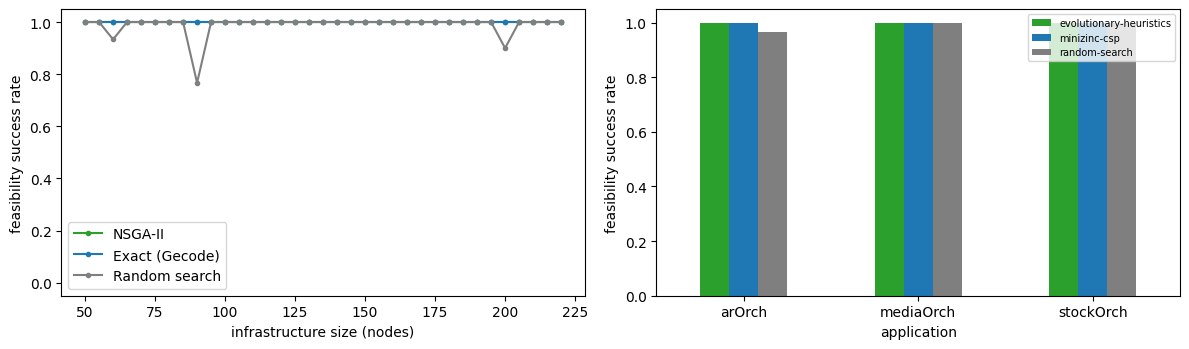

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for engine, group in runs.groupby('engine'):
    rate = group.groupby('infra_size').feasible.apply(lambda s: s.fillna(False).mean())
    axes[0].plot(rate.index, rate.values, marker='.',
                 color=ENGINE_COLORS.get(engine), label=ENGINE_LABELS.get(engine, engine))
axes[0].set(xlabel='infrastructure size (nodes)', ylabel='feasibility success rate', ylim=(-0.05, 1.05))
axes[0].legend()

rate_app = (runs.assign(feas=runs.feasible.fillna(False))
            .groupby(['application', 'engine']).feas.mean().unstack('engine'))
rate_app.plot(kind='bar', ax=axes[1], rot=0, color=[ENGINE_COLORS.get(c) for c in rate_app.columns])
axes[1].set(ylabel='feasibility success rate')
axes[1].legend(fontsize=7)
fig.tight_layout()
analysis.save_fig(fig, 'eval_feasibility_rates', FIGURES)

references = analysis.reference_objectives(runs, traces)
print(references.reference_source.value_counts().to_string())
fallback_instances = references[references.reference_source == 'heuristic_fallback']
if len(fallback_instances):
    print('\ninstances relying on the 1000-evaluation heuristic fallback:')
    display(fallback_instances)

## 3. Solution quality

> **Fair-comparison note.** Canonical J is normalized with *per-instance* bounds: values are
> directly comparable **between engines within an instance**, but raw J must not be averaged
> across instances (it would mix scales). The boxplots below are therefore descriptive,
> per-application views; every cross-instance conclusion in this notebook uses scale-free,
> per-instance-paired statistics: gap to reference (§3.4), % improvement vs the baseline (§3.3),
> performance profiles (§3.5) and mean ranks / Friedman + Â₁₂ (§7).

### 3.1 Canonical objective distributions per engine and application

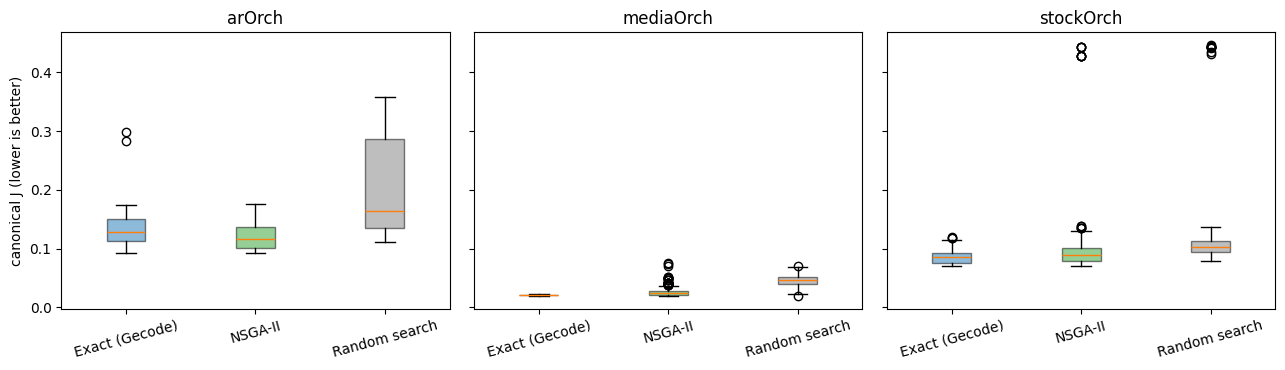

In [4]:
engines_order = [EXACT_ENGINE, 'evolutionary-heuristics', BASELINE_ENGINE]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (app, group) in zip(axes, ok.groupby('application')):
    data, labels, colors = [], [], []
    for engine in engines_order:
        values = group[group.engine == engine].objective_value.values
        if len(values):
            data.append(values)
            labels.append(ENGINE_LABELS.get(engine, engine))
            colors.append(ENGINE_COLORS.get(engine))
    parts = ax.boxplot(data, tick_labels=labels, patch_artist=True)
    for patch, color in zip(parts['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set(title=app)
    ax.tick_params(axis='x', rotation=15)
axes[0].set_ylabel('canonical J (lower is better)')
fig.tight_layout()
analysis.save_fig(fig, 'eval_objective_boxplots', FIGURES)

### 3.2 Median objective heatmap (engine × infrastructure size)

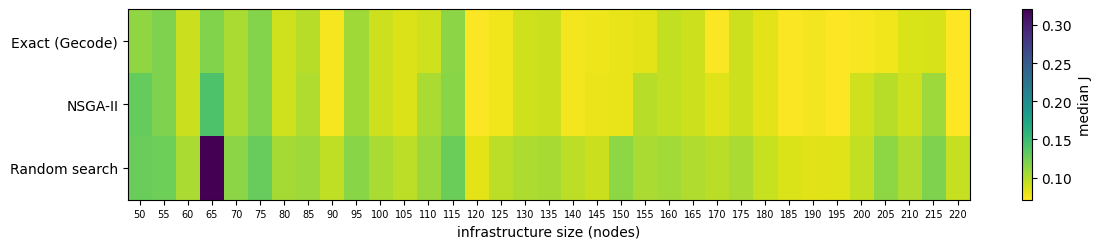

In [5]:
pivot = ok.groupby(['engine', 'infra_size']).objective_value.median().unstack('infra_size')
pivot = pivot.reindex([e for e in engines_order if e in pivot.index])
fig, ax = plt.subplots(figsize=(12, 2.6))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis_r')
ax.set_yticks(range(len(pivot.index)), labels=[ENGINE_LABELS.get(e, e) for e in pivot.index])
ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns, fontsize=7)
ax.set_xlabel('infrastructure size (nodes)')
fig.colorbar(im, label='median J')
fig.tight_layout()
analysis.save_fig(fig, 'eval_objective_heatmap', FIGURES)

### 3.3 Improvement over the random-search baseline

`improvement = (J_baseline − J_engine) / J_baseline` on per-instance medians; positive means better
than the baseline.

,instances(x100),25%,50%,75%
engine,,,,
evolutionary-heuristics,10500.0,12.98,20.66,51.12
minizinc-csp,10500.0,12.98,27.55,56.11


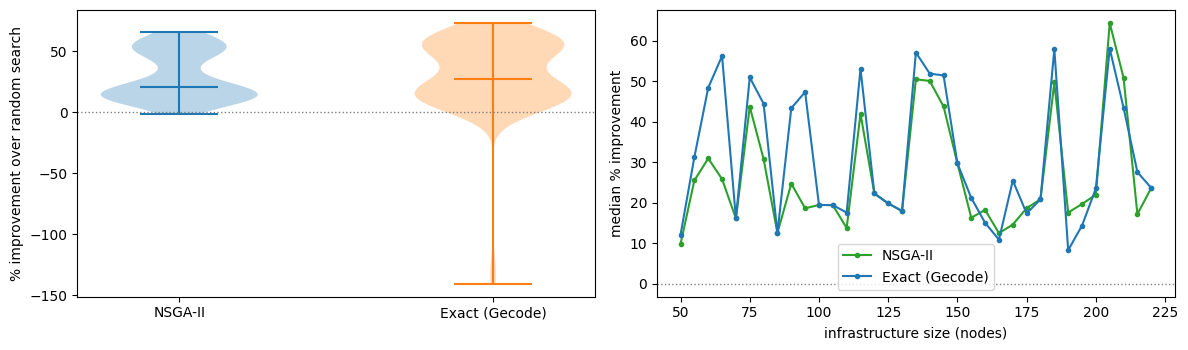

In [6]:
improvements = analysis.improvement_over_baseline(runs)

if improvements.empty:
    print('Baseline (random search) has no feasible runs on shared instances: '
          'improvements over it are undefined here — see the feasibility rates in §2.')
else:
    improvements['infra_size'] = improvements.instance_id.map(analysis.instance_size)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    engine_list = list(improvements.engine.unique())
    for engine, group in improvements.groupby('engine'):
        axes[0].violinplot(group.improvement_vs_baseline.values * 100,
                           positions=[engine_list.index(engine)], showmedians=True)
    axes[0].set_xticks(range(len(engine_list)),
                       labels=[ENGINE_LABELS.get(e, e) for e in engine_list])
    axes[0].axhline(0, color='gray', lw=1, ls=':')
    axes[0].set_ylabel('% improvement over random search')

    for engine, group in improvements.groupby('engine'):
        med = group.groupby('infra_size').improvement_vs_baseline.median() * 100
        axes[1].plot(med.index, med.values, marker='.',
                     color=ENGINE_COLORS.get(engine), label=ENGINE_LABELS.get(engine, engine))
    axes[1].axhline(0, color='gray', lw=1, ls=':')
    axes[1].set(xlabel='infrastructure size (nodes)', ylabel='median % improvement')
    axes[1].legend()
    fig.tight_layout()
    analysis.save_fig(fig, 'eval_improvement_over_baseline', FIGURES)

    display(improvements.groupby('engine').improvement_vs_baseline
            .describe()[['count', '25%', '50%', '75%']].mul(100).round(2)
            .rename(columns={'count': 'instances(x100)'}))

### 3.4 Gap to the per-instance reference

`gap = (J − reference_J) / reference_J`, split by reference source (proved optimum, exact anytime
incumbent, or heuristic 1 000-evaluation fallback). Negative gaps against `exact_incumbent` mean
the heuristic **beat the exact solver's anytime solution** within the same budget.

count     25%     50%     75%  \
engine                  reference_source                                  
evolutionary-heuristics exact_incumbent   160.0 -0.1597 -0.1306 -0.0375   
                        exact_optimal     890.0  0.0000  0.0011  0.1864   
random-search           exact_incumbent   157.0  0.0011  0.0681  0.2339   
                        exact_optimal     881.0  0.1676  0.4807  1.2890   

                                             max  
engine                  reference_source          
evolutionary-heuristics exact_incumbent   0.0122  
                        exact_optimal     2.7348  
random-search           exact_incumbent   1.8771  
                        exact_optimal     2.7692

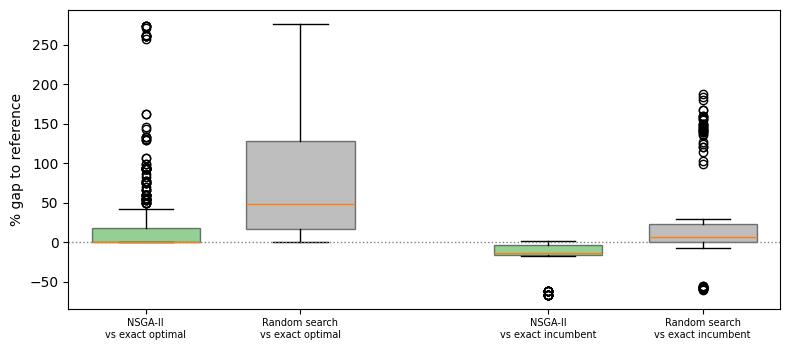

In [7]:
gaps = analysis.gaps_to_reference(runs, references)

if gaps.empty:
    print('No feasible heuristic runs with a defined reference — nothing to plot.')
else:
    display(gaps.groupby(['engine', 'reference_source']).gap
            .describe()[['count', '25%', '50%', '75%', 'max']].round(4))

    fig, ax = plt.subplots(figsize=(8, 3.6))
    positions, ticklabels = [], []
    pos = 0
    for source in ('exact_optimal', 'exact_incumbent', 'heuristic_fallback'):
        for engine in ('evolutionary-heuristics', BASELINE_ENGINE):
            values = gaps[(gaps.engine == engine) & (gaps.reference_source == source)].gap.values * 100
            if len(values):
                box = ax.boxplot([values], positions=[pos], widths=0.7, patch_artist=True)
                box['boxes'][0].set_facecolor(ENGINE_COLORS.get(engine))
                box['boxes'][0].set_alpha(0.5)
                positions.append(pos)
                ticklabels.append(f"{ENGINE_LABELS.get(engine, engine)}\nvs {source.replace('_', ' ')}")
                pos += 1
        pos += 0.6
    ax.axhline(0, color='gray', lw=1, ls=':')
    ax.set_xticks(positions, labels=ticklabels, fontsize=7)
    ax.set_ylabel('% gap to reference')
    fig.tight_layout()
    analysis.save_fig(fig, 'eval_gap_to_reference', FIGURES)

### 3.5 Performance profiles (Dolan–Moré)

`ρ_e(τ)` = fraction of the 105 instances where engine *e*'s median J is within a factor τ of the
best median on that instance — the standard tool for comparing solvers across a benchmark.

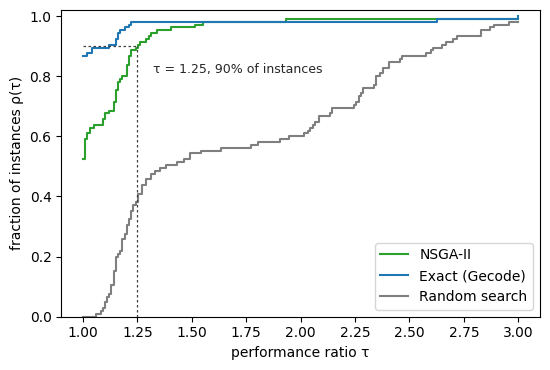

In [8]:
taus, profiles = analysis.performance_profile(runs)
# Same figsize as eval_gap_ecdf: both render side by side in the paper.
fig, ax = plt.subplots(figsize=(5.6, 3.8))
for engine, rho in profiles.items():
    ax.step(taus, rho, where='post', color=ENGINE_COLORS.get(engine),
            label=ENGINE_LABELS.get(engine, engine))
# Dashed guide: NSGA-II stays within a factor 1.25 of the best median on
# ~90% of the instances (partial segments meeting at the guide point).
GUIDE_TAU, GUIDE_RHO = 1.25, 0.90
GUIDE_STYLE = dict(color='0.25', lw=0.9, ls=(0, (2, 2)))
ax.plot([GUIDE_TAU, GUIDE_TAU], [0, GUIDE_RHO], **GUIDE_STYLE)
ax.plot([taus.min(), GUIDE_TAU], [GUIDE_RHO, GUIDE_RHO], **GUIDE_STYLE)
ax.annotate(f'τ = {GUIDE_TAU}, {GUIDE_RHO:.0%} of instances',
            xy=(GUIDE_TAU, GUIDE_RHO), xytext=(GUIDE_TAU + 0.07, GUIDE_RHO - 0.09),
            fontsize=9, color='0.15',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
ax.set(xlabel='performance ratio τ', ylabel='fraction of instances ρ(τ)', ylim=(0, 1.02))
ax.legend()
fig.tight_layout()
analysis.save_fig(fig, 'eval_performance_profiles', FIGURES)

### 3.6 From feasible to optimal: what optimization adds over a valid placement

The first feasible best-so-far event of each run is the closest observable proxy for what a
feasibility-oriented placer (eligibility-only, à la SecFaaS2Fog) returns.
`optimization_gain = (J_first_feasible − J_best) / J_first_feasible` quantifies the quality
forgone when placement stops at validity instead of optimizing under the same constraints.

Because per-instance normalization makes raw `J` values incomparable across instances (pooling
them mixes scales and visually hides the engine difference), both panels use **relative gaps to
the proven optimum**, restricted to the 89 proven-optimal instances where gaps are ≥ 0 by
construction; runs that end exactly at the optimum are clipped onto the axis floor. The scatter
pairs each run's first feasible solution with its final best (log–log); the ECDFs show the same
gaps as distributions before (dashed) and after (solid) continuing the search: both engines start
from near-identical first-feasible quality (median gap ≈ 270%, overlapping dashed curves), but
only NSGA-II collapses onto the optimum — its solid curve jumps to 0.5 at the floor because half
of its runs end exactly there — while random search stalls well above it under the same budget.

The second cell exports the ECDF panel alone (`eval_gap_ecdf`) for the paper, where it sits as a
subfigure next to the performance profiles. There the floor-clipping hack is replaced by a
**symlog** x-axis: linear around 0 and logarithmic beyond, so gap-0 runs sit on a true "0" tick
slightly inset from the plot corner, and dashed guides mark the medians quoted in the text.

,runs(x100),25%,50%,75%
engine,,,,
evolutionary-heuristics,105000.0,62.36,68.30,87.32
random-search,103800.0,52.84,63.32,81.04


median J: first feasible vs final best


,J_first_feasible,J_best
engine,,
evolutionary-heuristics,0.2922,0.0897
random-search,0.2925,0.1023


runs ending exactly at the proven optimum: {'evolutionary-heuristics': 444, 'random-search': 1}
median % gaps to the optimum (first feasible / final best):


,gap_first,gap_best
engine,,
evolutionary-heuristics,267.82,0.11
random-search,271.89,48.07


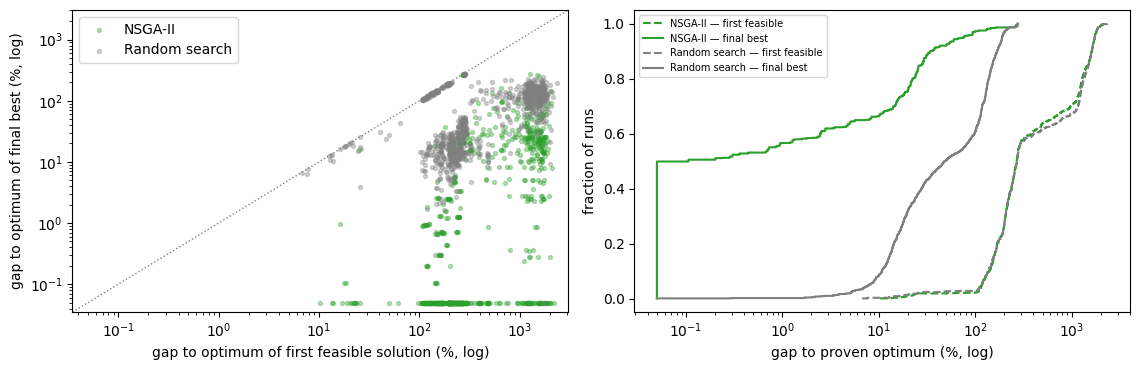

In [9]:
ffb = analysis.first_feasible_vs_best(traces)
ffb = ffb[ffb.engine != EXACT_ENGINE].merge(references, on='instance_id')

display(ffb.groupby('engine').optimization_gain
        .describe()[['count', '25%', '50%', '75%']].mul(100).round(2)
        .rename(columns={'count': 'runs(x100)'}))
print('median J: first feasible vs final best')
display(ffb.groupby('engine')[['J_first_feasible', 'J_best']].median().round(4))

# Scale-free view on the proven-optimal instances; runs that end exactly at
# the optimum are clipped onto the axis floor so the log scale can show them.
FLOOR = 5e-4
opt = ffb[ffb.reference_source == 'exact_optimal'].copy()
opt['gap_first'] = (opt.J_first_feasible - opt.reference_J) / opt.reference_J
opt['gap_best'] = (opt.J_best - opt.reference_J) / opt.reference_J
print('runs ending exactly at the proven optimum:',
      (opt.gap_best <= 1e-9).groupby(opt.engine).sum().to_dict())
print('median % gaps to the optimum (first feasible / final best):')
display(opt.groupby('engine')[['gap_first', 'gap_best']].median().mul(100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for engine, group in opt.groupby('engine'):
    axes[0].scatter(group.gap_first.clip(lower=FLOOR) * 100,
                    group.gap_best.clip(lower=FLOOR) * 100, s=8, alpha=0.35,
                    color=ENGINE_COLORS.get(engine), label=ENGINE_LABELS.get(engine, engine))
lims = [FLOOR * 100 * 0.7, max(opt.gap_first.max(), opt.gap_best.max()) * 100 * 1.3]
axes[0].plot(lims, lims, color='gray', lw=1, ls=':')
axes[0].set(xscale='log', yscale='log', xlim=lims, ylim=lims,
            xlabel='gap to optimum of first feasible solution (%, log)',
            ylabel='gap to optimum of final best (%, log)')
axes[0].legend()

for engine, group in opt.groupby('engine'):
    color = ENGINE_COLORS.get(engine)
    for col, style, label in (('gap_first', '--', 'first feasible'),
                              ('gap_best', '-', 'final best')):
        x, y = analysis.ecdf(group[col].clip(lower=FLOOR).values * 100)
        axes[1].step(x, y, style, where='post', color=color,
                     label=f'{ENGINE_LABELS.get(engine, engine)} — {label}')
axes[1].set(xscale='log', xlabel='gap to proven optimum (%, log)',
            ylabel='fraction of runs')
axes[1].legend(fontsize=7)
fig.tight_layout()
analysis.save_fig(fig, 'eval_first_feasible_vs_best', FIGURES)

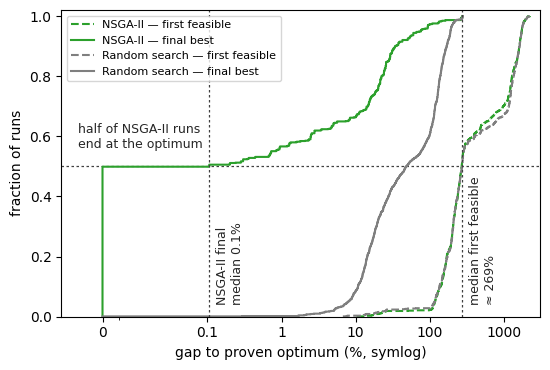

In [10]:
# Paper export: the ECDF panel above as a standalone figure sized for a
# side-by-side subfigure. Instead of clipping optimal runs onto a log-axis
# floor, a symlog x-axis (linear within ±LINTHRESH %, logarithmic beyond)
# shows a true 0 tick slightly inset from the plot corner, so runs that end
# exactly at the proven optimum sit visibly on the 0 line.
LINTHRESH = 0.05  # width of the linear region around 0, in % units
# Short-dash near-black guides: distinguishable from the gray dashed
# random-search curve; white boxes keep labels legible over the curves.
GUIDE_STYLE = dict(color='0.25', lw=0.9, ls=(0, (2, 2)))
LABEL_STYLE = dict(fontsize=9, color='0.15',
                   bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
med_first = opt.gap_first.median() * 100
med_best_nsga = opt[opt.engine == 'evolutionary-heuristics'].gap_best.median() * 100
max_gap = max(opt.gap_first.max(), opt.gap_best.max()) * 100

fig, ax = plt.subplots(figsize=(5.6, 3.8))
for engine, group in opt.groupby('engine'):
    color = ENGINE_COLORS.get(engine)
    for col, style, label in (('gap_first', '--', 'first feasible'),
                              ('gap_best', '-', 'final best')):
        x, y = analysis.ecdf(group[col].values * 100)
        ax.step(x, y, style, where='post', color=color,
                label=f'{ENGINE_LABELS.get(engine, engine)} — {label}')
# Dashed guides at the medians quoted in the paper text, plus RQ2's headline
# fact: half of the NSGA-II runs end exactly at the proven optimum
# (horizontal guide at 0.5, drawn behind the curves, labelled at the jump).
for value, text in ((med_first, f'median first feasible\n≈ {med_first:.0f}%'),
                    (med_best_nsga, f'NSGA-II final\nmedian {med_best_nsga:.1f}%')):
    ax.axvline(value, **GUIDE_STYLE)
    ax.annotate(text, xy=(value, 0.04), xytext=(value * 1.25, 0.04),
                rotation=90, va='bottom', ha='left', **LABEL_STYLE)
ax.axhline(0.5, zorder=1, **GUIDE_STYLE)
ax.annotate('half of NSGA-II runs\nend at the optimum', xy=(-0.015, 0.55),
            ha='left', va='bottom', **LABEL_STYLE)
ax.set_xscale('symlog', linthresh=LINTHRESH)
ax.set_xlim(-LINTHRESH / 2, max_gap * 1.3)
ticks = [t for t in (0, 0.1, 1, 10, 100, 1000) if t <= max_gap * 1.3]
ax.set_xticks(ticks, labels=[f'{t:g}' for t in ticks])
ax.set(xlabel='gap to proven optimum (%, symlog)', ylabel='fraction of runs',
       ylim=(0, 1.02))
ax.legend(fontsize=8)
fig.tight_layout()
analysis.save_fig(fig, 'eval_gap_ecdf', FIGURES)

## 4. Runtime and completion status

Heuristic lanes always consume the shared budget T; the exact engine terminates early when it
proves optimality. `engine_execution_time_ms` isolates solver time from gateway overhead.

,instances
solver_status,
OPTIMAL,89
SATISFIED,16


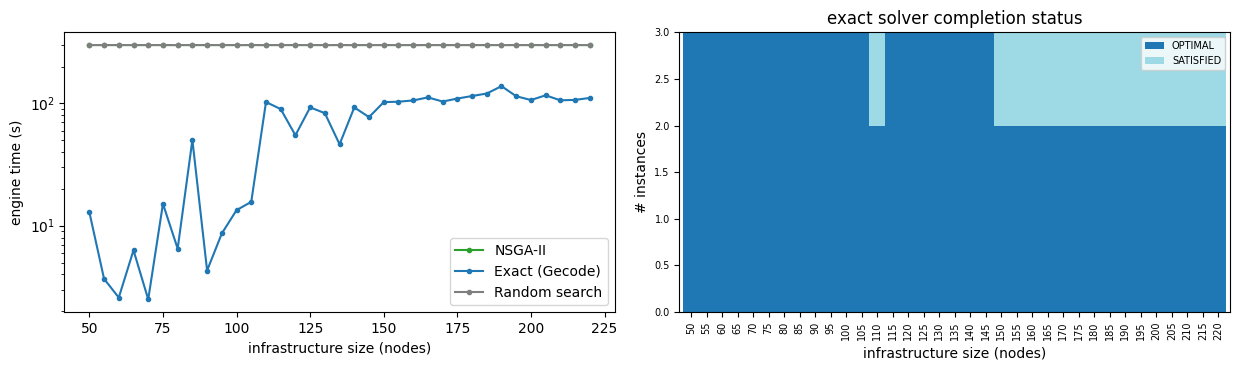

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
for engine, group in runs.groupby('engine'):
    means = group.groupby('infra_size').engine_execution_time_ms.mean() / 1000
    axes[0].plot(means.index, means.values, marker='.',
                 color=ENGINE_COLORS.get(engine), label=ENGINE_LABELS.get(engine, engine))
axes[0].set(xlabel='infrastructure size (nodes)', ylabel='engine time (s)', yscale='log')
axes[0].legend()

mzn = runs[runs.engine == EXACT_ENGINE].copy()
mzn['solver_status'] = mzn.solver_status.fillna('NO_SOLUTION')
status = mzn.groupby(['infra_size', 'solver_status']).size().unstack(fill_value=0)
status.plot(kind='bar', stacked=True, ax=axes[1], width=1.0,
            colormap='tab20', fontsize=7)
axes[1].set(xlabel='infrastructure size (nodes)', ylabel='# instances',
            title='exact solver completion status')
axes[1].legend(fontsize=7)
fig.tight_layout()
analysis.save_fig(fig, 'eval_runtime_and_status', FIGURES)

display(mzn.groupby('solver_status').size().rename('instances').to_frame())

## 5. Stopping-criterion study

### 5.1 Time to first feasible solution and time to best (ECDFs)

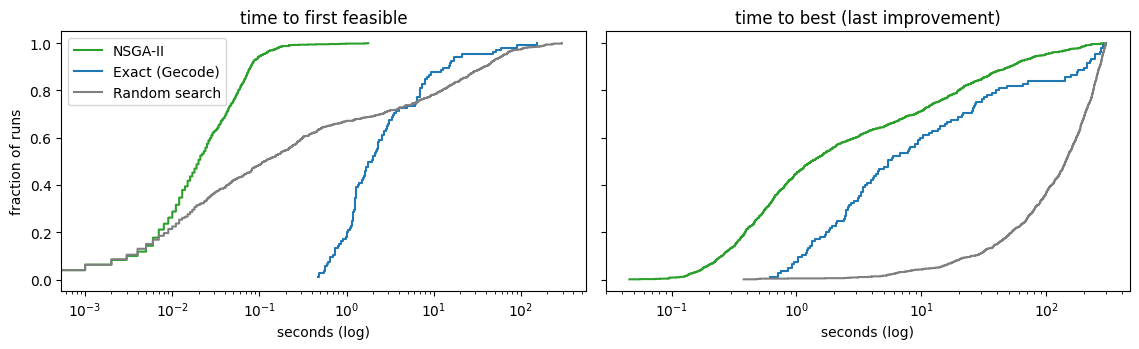

In [12]:
feas_traces = traces[traces.feasible == True]
first_feasible = feas_traces.groupby(['engine', 'run_id']).elapsed_ms.min().reset_index()
time_to_best = feas_traces.groupby(['engine', 'run_id']).elapsed_ms.max().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True)
for ax, (df, title) in zip(axes, [(first_feasible, 'time to first feasible'),
                                  (time_to_best, 'time to best (last improvement)')]):
    for engine, group in df.groupby('engine'):
        x, y = analysis.ecdf(group.elapsed_ms.values / 1000)
        ax.step(x, y, where='post', color=ENGINE_COLORS.get(engine),
                label=ENGINE_LABELS.get(engine, engine))
    ax.set(xlabel='seconds (log)', xscale='log', title=title)
axes[0].set_ylabel('fraction of runs')
axes[0].legend()
fig.tight_layout()
analysis.save_fig(fig, 'eval_time_ecdfs', FIGURES)

### 5.2 When does the last improvement happen?

If improvements concentrate early, most of the time budget is spent without progress — the
empirical argument for/against pure time-based stopping.

,median_last_eval,p90_last_eval,median_last_s,p90_last_s
engine,,,,
evolutionary-heuristics,9849.5,342422.5,1.3,50.4
random-search,1058749.5,2319161.1,142.8,266.8


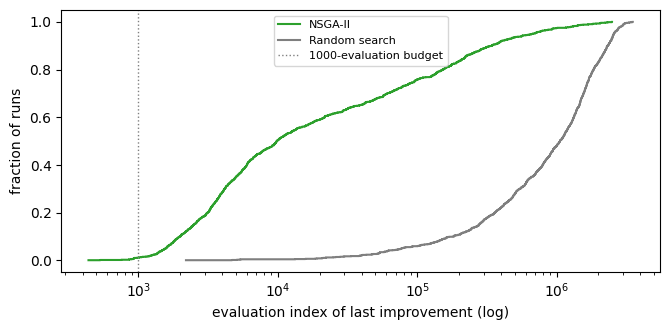

In [13]:
last = (feas_traces[feas_traces.eval_index.notna()]
        .groupby(['engine', 'run_id'])[['eval_index', 'elapsed_ms']].max().reset_index())
summary = last.groupby('engine').agg(
    median_last_eval=('eval_index', 'median'),
    p90_last_eval=('eval_index', lambda s: s.quantile(0.9)),
    median_last_s=('elapsed_ms', lambda s: s.median() / 1000),
    p90_last_s=('elapsed_ms', lambda s: s.quantile(0.9) / 1000),
)
display(summary.round(1))

fig, ax = plt.subplots(figsize=(6.8, 3.4))
for engine, group in last.groupby('engine'):
    x, y = analysis.ecdf(group.eval_index.values)
    ax.step(x, y, where='post', color=ENGINE_COLORS.get(engine),
            label=ENGINE_LABELS.get(engine, engine))
ax.axvline(1000, color='gray', ls=':', lw=1, label='1000-evaluation budget')
ax.set(xlabel='evaluation index of last improvement (log)', xscale='log',
       ylabel='fraction of runs')
ax.legend(fontsize=8)
fig.tight_layout()
analysis.save_fig(fig, 'eval_last_improvement', FIGURES)

### 5.3 What would the classic 1 000-evaluation budget have missed?

Offline cutoff study from the traces: J at 1 000 evaluations vs J at the full budget T.

,J_at_1000,J_at_T,median_gain_after_1000_evals
engine,,,
evolutionary-heuristics,0.12028,0.08959,0.02054
random-search,0.20488,0.05299,0.15498


runs feasible at T but NOT within the first 1000 evaluations:
engine
evolutionary-heuristics      3
random-search              505


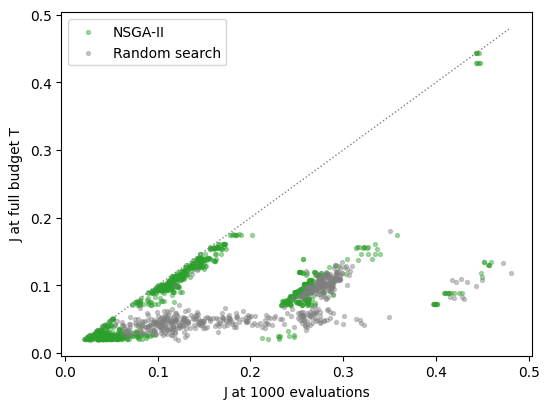

In [14]:
j_1000 = analysis.j_at_cutoff(traces, eval_cutoff=1000).rename(columns={'J': 'J_at_1000'})
j_full = analysis.j_at_cutoff(traces).rename(columns={'J': 'J_at_T'})
cutoff = j_1000.merge(j_full[['run_id', 'J_at_T']], on='run_id', how='outer')
cutoff['engine'] = cutoff.engine.fillna(cutoff.run_id.str.split('|').str[1].str.split('#').str[0])
cutoff = cutoff[cutoff.engine != EXACT_ENGINE]
cutoff['gain'] = cutoff.J_at_1000 - cutoff.J_at_T

both = cutoff.dropna(subset=['J_at_1000', 'J_at_T'])
if both.empty:
    print('No run has feasible values at both cutoffs — skipping the scatter.')
else:
    fig, ax = plt.subplots(figsize=(5.6, 4.2))
    for engine, group in both.groupby('engine'):
        ax.scatter(group.J_at_1000, group.J_at_T, s=8, alpha=0.4,
                   color=ENGINE_COLORS.get(engine), label=ENGINE_LABELS.get(engine, engine))
    lims = [np.nanmin(both[['J_at_1000', 'J_at_T']].values),
            np.nanmax(both[['J_at_1000', 'J_at_T']].values)]
    ax.plot(lims, lims, color='gray', lw=1, ls=':')
    ax.set(xlabel='J at 1000 evaluations', ylabel='J at full budget T')
    ax.legend()
    fig.tight_layout()
    analysis.save_fig(fig, 'eval_cutoff_1000_vs_T', FIGURES)

    display(both.groupby('engine')[['J_at_1000', 'J_at_T', 'gain']].median()
            .rename(columns={'gain': 'median_gain_after_1000_evals'}).round(5))

print('runs feasible at T but NOT within the first 1000 evaluations:')
print(cutoff.groupby('engine').apply(
    lambda g: (g.J_at_1000.isna() & g.J_at_T.notna()).sum(), include_groups=False).to_string())

### 5.4 Time to reach the exact reference

For each instance, the elapsed time at which NSGA-II's feasible best-so-far first enters the
reference region (exact match, 1% and 5% tolerance). Per instance, the median over the 10 seeds
is taken with non-reaching seeds counted as +inf, so an instance only counts as *reached* when
the **majority of its seeds** gets there within T. Compared against the exact solver's own time,
split by its completion status — the operational argument for anytime rebinding: where the exact
solver saturates its budget (`SATISFIED`), NSGA-II delivers the same quality orders of magnitude
faster.

,instances reached (majority of seeds),median t_reach (s),p90 t_reach (s)
tol 0%,55.0,2.73,37.70
tol 1%,62.0,1.23,27.24
tol 5%,67.0,0.41,16.08


instances not reached within 1% (majority of seeds), by reference source:
reference_source
exact_optimal    43

seeds reaching within 1% on the 62 reported instances: min 60%, quartiles 100%/100%/100%; all 10 seeds reach it in 47 instances


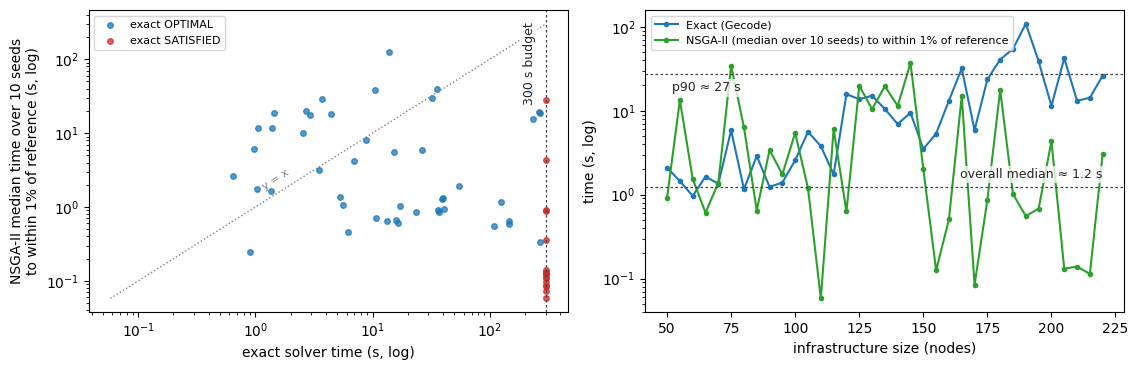

In [15]:
tolerances = (0.0, 0.01, 0.05)
ttr = {tol: analysis.time_to_reference(runs, traces, references, tolerance=tol)
       for tol in tolerances}

display(pd.DataFrame({
    f'tol {tol:.0%}': {
        'instances reached (majority of seeds)': int(t.t_reach_ms.notna().sum()),
        'median t_reach (s)': t.t_reach_ms.median() / 1000,
        'p90 t_reach (s)': t.t_reach_ms.quantile(0.9) / 1000,
    } for tol, t in ttr.items()
}).T.round(2))

sel = ttr[0.01].copy()
sel['infra_size'] = sel.instance_id.map(analysis.instance_size)
print('instances not reached within 1% (majority of seeds), by reference source:')
print(sel[sel.t_reach_ms.isna()].reference_source.value_counts().to_string())

# How many of the 10 seeds reach the region on the reported instances —
# evidence that the metric aggregates all seeds, not a lucky run.
reached = sel[sel.t_reach_ms.notna()]
print(f'\nseeds reaching within 1% on the {len(reached)} reported instances: '
      f'min {reached.reach_rate.min():.0%}, quartiles '
      f'{reached.reach_rate.quantile(0.25):.0%}/{reached.reach_rate.median():.0%}/'
      f'{reached.reach_rate.quantile(0.75):.0%}; all 10 seeds reach it in '
      f'{(reached.reach_rate >= 0.999).sum()} instances')

status_colors = {'OPTIMAL': ENGINE_COLORS[EXACT_ENGINE], 'SATISFIED': '#d62728'}
BUDGET_S = 300  # shared wall-clock budget T
GUIDE_STYLE = dict(color='0.25', lw=0.9, ls=(0, (2, 2)))
LABEL_STYLE = dict(fontsize=9, color='0.15',
                   bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for status, group in reached.groupby('solver_status'):
    axes[0].scatter(group.exact_ms / 1000, group.t_reach_ms / 1000, s=16, alpha=0.75,
                    color=status_colors.get(status), label=f'exact {status}')
lims = [min(reached.exact_ms.min(), reached.t_reach_ms.min()) / 1000,
        max(reached.exact_ms.max(), reached.t_reach_ms.max()) / 1000]
axes[0].plot(lims, lims, color='gray', lw=1, ls=':')
axes[0].annotate('y = x', xy=(1.1, 1.7), rotation=33, fontsize=8, color='gray')
# Dashed guide: exact runs piling up on the right edge hit the time budget.
axes[0].axvline(BUDGET_S, **GUIDE_STYLE)
axes[0].annotate(f'{BUDGET_S} s budget', xy=(BUDGET_S * 0.82, 0.96),
                 xycoords=('data', 'axes fraction'), rotation=90,
                 va='top', ha='right', **LABEL_STYLE)
axes[0].set(xlabel='exact solver time (s, log)',
            ylabel='NSGA-II median time over 10 seeds\nto within 1% of reference (s, log)',
            xscale='log', yscale='log')
axes[0].legend(fontsize=8)

# Per-size medians: NaNs (non-reached instances) are skipped, so large sizes
# may aggregate fewer than 3 instances per point.
med = sel.groupby('infra_size').agg(nsga=('t_reach_ms', 'median'),
                                    exact=('exact_ms', 'median'))
axes[1].plot(med.index, med.exact / 1000, marker='.',
             color=ENGINE_COLORS[EXACT_ENGINE], label='Exact (Gecode)')
axes[1].plot(med.index, med.nsga / 1000, marker='.',
             color=ENGINE_COLORS['evolutionary-heuristics'],
             label='NSGA-II (median over 10 seeds) to within 1% of reference')
# Dashed guides at the overall NSGA-II median and p90 quoted in the paper.
med_overall = reached.t_reach_ms.median() / 1000
p90_overall = reached.t_reach_ms.quantile(0.9) / 1000
axes[1].axhline(med_overall, **GUIDE_STYLE)
axes[1].annotate(f'overall median ≈ {med_overall:.1f} s',
                 xy=(med.index.max(), med_overall * 1.18),
                 ha='right', va='bottom', **LABEL_STYLE)
axes[1].axhline(p90_overall, **GUIDE_STYLE)
axes[1].annotate(f'p90 ≈ {p90_overall:.0f} s',
                 xy=(med.index.min() + 2, p90_overall * 0.82),
                 ha='left', va='top', **LABEL_STYLE)
axes[1].set(xlabel='infrastructure size (nodes)', ylabel='time (s, log)', yscale='log')
axes[1].legend(fontsize=8)
fig.tight_layout()
analysis.save_fig(fig, 'eval_time_to_reference', FIGURES)

### 5.5 Budget utilization: evaluations completed within T

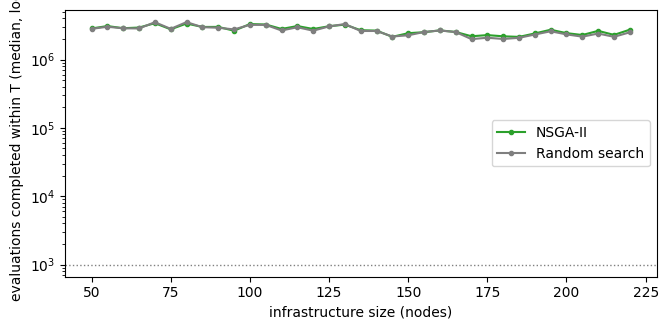

In [16]:
# Exact budget utilization: total evaluations completed within T, recorded by
# the engines (runs.engine_evaluations). Falls back to the index of the last
# improvement (a lower bound from the traces) for older runs.csv files.
heur = runs[runs.engine != EXACT_ENGINE].copy()
if 'engine_evaluations' in heur.columns and heur.engine_evaluations.notna().any():
    evals = (heur[['engine', 'run_id', 'engine_evaluations']]
             .dropna().rename(columns={'engine_evaluations': 'observed_evals'}))
    ylabel = 'evaluations completed within T (median, log)'
else:
    evals = (traces[traces.eval_index.notna()]
             .groupby(['engine', 'run_id']).eval_index.max().reset_index()
             .rename(columns={'eval_index': 'observed_evals'}))
    ylabel = 'evaluations at last improvement (median, log)'
evals['infra_size'] = evals.run_id.map(analysis.instance_size)

fig, ax = plt.subplots(figsize=(6.8, 3.4))
for engine, group in evals.groupby('engine'):
    med = group.groupby('infra_size').observed_evals.median()
    ax.plot(med.index, med.values, marker='.', color=ENGINE_COLORS.get(engine),
            label=ENGINE_LABELS.get(engine, engine))
ax.set(xlabel='infrastructure size (nodes)', ylabel=ylabel, yscale='log')
ax.axhline(1000, color='gray', ls=':', lw=1)
ax.legend()
fig.tight_layout()
analysis.save_fig(fig, 'eval_budget_utilization', FIGURES)


## 6. Convergence examples

Best-so-far convergence on three representative instances spanning the size range, shown as the
median and IQR band over the stochastic seeds; the time view also overlays the exact engine's
incumbent staircase.

example instances: ['arOrch_146588263_infrastructure_50', 'mediaOrch_146588263_infrastructure_135', 'stockOrch_146588263_infrastructure_220']


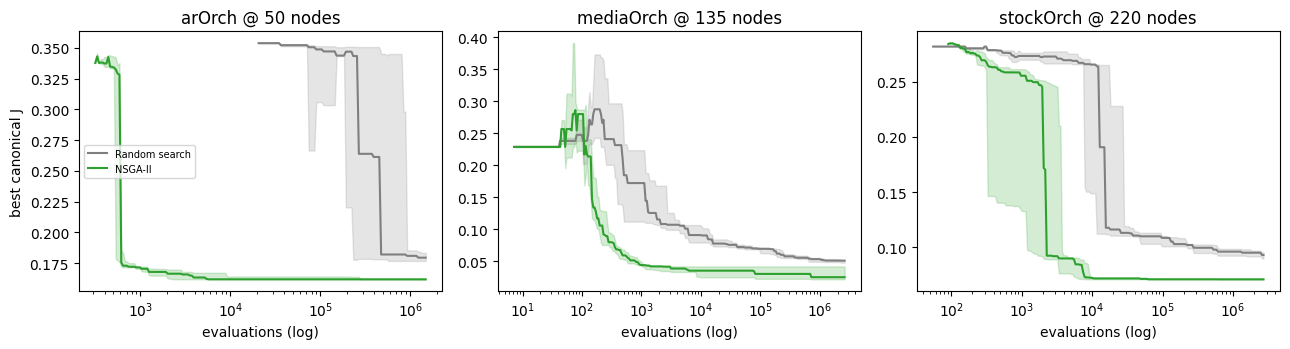

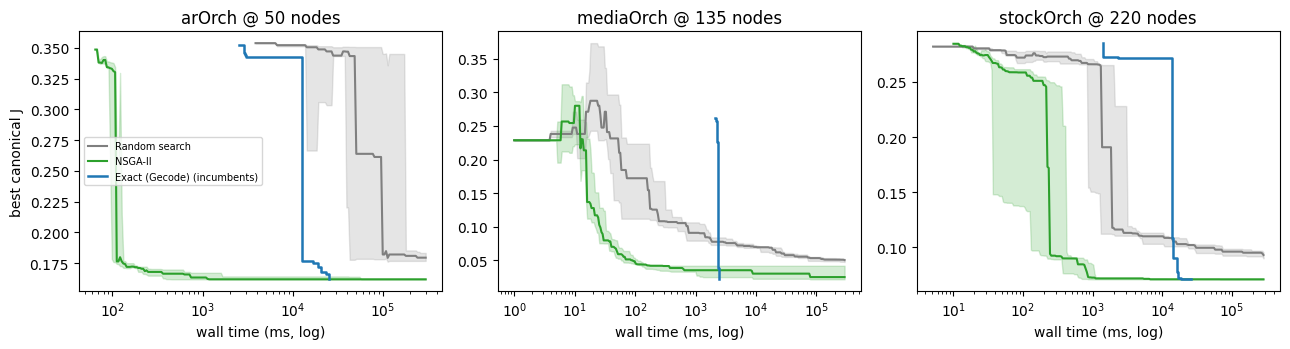

In [17]:
def pick_example_instances(max_examples=3):
    """Representative instances present in the traces, spanning sizes.

    Ties within a size are broken by instance id so the selection (and the
    exported figures) is deterministic across runs.
    """
    available = sorted({r.split('|')[0] for r in traces.run_id.unique()},
                       key=lambda i: (analysis.instance_size(i), i))
    if len(available) <= max_examples:
        return available
    idx = np.linspace(0, len(available) - 1, max_examples).astype(int)
    return [available[i] for i in idx]


def plot_convergence(instances, x_field, xlabel, fname):
    fig, axes = plt.subplots(1, len(instances), figsize=(13, 3.6))
    for ax, inst in zip(np.atleast_1d(axes), instances):
        inst_traces = traces[traces.run_id.str.startswith(inst + '|')]
        max_x = inst_traces[x_field].max()
        if not np.isfinite(max_x):
            continue
        grid = np.unique(np.logspace(0, np.log10(max(10, max_x)), 300))
        for engine in ('random-search', 'evolutionary-heuristics'):
            band = analysis.convergence_band(traces, inst, engine, grid, x=x_field)
            if band is None:
                continue
            color = ENGINE_COLORS.get(engine)
            ax.plot(grid, band['median'], color=color, label=ENGINE_LABELS.get(engine, engine))
            ax.fill_between(grid, band['q1'], band['q3'], color=color, alpha=0.2)
        if x_field == 'elapsed_ms':
            inc = inst_traces[(inst_traces.engine == EXACT_ENGINE) & (inst_traces.source == 'incumbent')]
            if not inc.empty:
                inc = inc.sort_values('elapsed_ms')
                ax.step(inc.elapsed_ms, inc.best_objective, where='post',
                        color=ENGINE_COLORS[EXACT_ENGINE], lw=1.8,
                        label=ENGINE_LABELS[EXACT_ENGINE] + ' (incumbents)')
        size = analysis.instance_size(inst)
        ax.set(title=f'{inst.split("_")[0]} @ {size} nodes', xlabel=xlabel, xscale='log')
    handles, labels = np.atleast_1d(axes)[0].get_legend_handles_labels()
    if handles:
        np.atleast_1d(axes)[0].legend(fontsize=7)
    np.atleast_1d(axes)[0].set_ylabel('best canonical J')
    fig.tight_layout()
    analysis.save_fig(fig, fname, FIGURES)

examples = pick_example_instances()
print('example instances:', examples)
plot_convergence(examples, 'eval_index', 'evaluations (log)', 'eval_convergence_vs_evals')
plot_convergence(examples, 'elapsed_ms', 'wall time (ms, log)', 'eval_convergence_vs_time')

## 7. Statistical comparison (10 seeds per instance)

Per-instance two-sided Mann–Whitney U between the stochastic engines plus the Vargha–Delaney Â₁₂
effect size (values > 0.5 favour the first engine for minimization). With 10 repetitions the
statistical power is limited (30 would be ideal); effect sizes are therefore reported alongside
p-values, and aggregated as win/tie/loss counts at α = 0.05.

instances compared: 105
winner
evolutionary-heuristics    101
tie                          4
median A12 (NSGA-II vs RS; >0.5 favours NSGA-II): 1.000


,instance_id,n_a,n_b,p_value,A12_evolutionary-heuristics_vs_random-search,median_a,median_b,winner,infra_size
0,arOrch_146588263_infrastructure_100,10,10,0.000141,1.0,0.136686,0.169693,evolutionary-heuristics,100
1,arOrch_146588263_infrastructure_105,10,10,0.000064,1.0,0.110529,0.137145,evolutionary-heuristics,105
2,arOrch_146588263_infrastructure_110,10,10,0.000064,1.0,0.113798,0.131952,evolutionary-heuristics,110
3,arOrch_146588263_infrastructure_115,10,10,0.000141,1.0,0.155870,0.332343,evolutionary-heuristics,115
4,arOrch_146588263_infrastructure_120,10,10,0.000087,1.0,0.092658,0.119225,evolutionary-heuristics,120
5,arOrch_146588263_infrastructure_125,10,10,0.000146,1.0,0.116080,0.137314,evolutionary-heuristics,125
6,arOrch_146588263_infrastructure_130,10,10,0.000087,1.0,0.116840,0.142416,evolutionary-heuristics,130
7,arOrch_146588263_infrastructure_135,10,10,0.000173,1.0,0.099506,0.280232,evolutionary-heuristics,135
8,arOrch_146588263_infrastructure_140,10,10,0.000064,1.0,0.099013,0.205846,evolutionary-heuristics,140
9,arOrch_146588263_infrastructure_145,10,10,0.000064,1.0,0.098203,0.281504,evolutionary-heuristics,145



Mean ranks over instances (1 = best; engines without a feasible run rank worst):


,mean_rank
Exact (Gecode),1.366667
NSGA-II,1.680952
Random search,2.952381


Friedman test over 105 instances: chi2 = 164.06, p = 2.37e-36


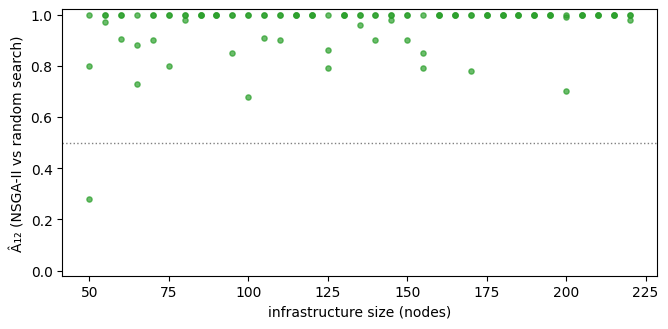

In [18]:
stats = analysis.pairwise_engine_stats(runs, 'evolutionary-heuristics', BASELINE_ENGINE)
if len(stats):
    effect_col = [c for c in stats.columns if c.startswith('A12')][0]
    print(f'instances compared: {len(stats)}')
    print(stats.winner.value_counts().rename('win/tie/loss (alpha=0.05)').to_string())
    print(f'median A12 (NSGA-II vs RS; >0.5 favours NSGA-II): {stats[effect_col].median():.3f}')

    stats['infra_size'] = stats.instance_id.map(analysis.instance_size)
    fig, ax = plt.subplots(figsize=(6.8, 3.4))
    ax.scatter(stats.infra_size, stats[effect_col], s=14, alpha=0.7, color='#2ca02c')
    ax.axhline(0.5, color='gray', ls=':', lw=1)
    ax.set(xlabel='infrastructure size (nodes)', ylabel='Â₁₂ (NSGA-II vs random search)',
           ylim=(-0.02, 1.02))
    fig.tight_layout()
    analysis.save_fig(fig, 'eval_effect_sizes', FIGURES)
    display(stats.head(10))

# Demšar-style overall comparison: mean ranks over instances + Friedman test.
# Rank-based aggregation is scale-free, hence safe across instances.
ranks, friedman = analysis.mean_ranks(runs)
print('\nMean ranks over instances (1 = best; engines without a feasible run rank worst):')
display(ranks.to_frame().rename(index=lambda e: ENGINE_LABELS.get(e, e)))
if 'friedman_p_value' in friedman:
    print(f"Friedman test over {friedman['n_instances']} instances: "
          f"chi2 = {friedman['friedman_statistic']:.2f}, p = {friedman['friedman_p_value']:.2e}")

## 8. Exported artifacts

All figures are written to `out/results/figures/` as `eval_*.pdf` (paper-ready, tight bounding
box) and `eval_*.png` (preview):

| Figure | Content |
|---|---|
| `eval_feasibility_rates` | success rate per engine vs size and per application |
| `eval_objective_boxplots` | J distributions per engine × application |
| `eval_objective_heatmap` | median J, engine × size |
| `eval_improvement_over_baseline` | % improvement vs random search |
| `eval_gap_to_reference` | gap to optimum / incumbent / fallback reference |
| `eval_performance_profiles` | Dolan–Moré profiles over the 105 instances |
| `eval_first_feasible_vs_best` | first valid placement vs optimized binding (feasible→optimal gain) |
| `eval_gap_ecdf` | paper subfigure: gap ECDFs alone, symlog axis with a true 0 tick |
| `eval_runtime_and_status` | engine time vs size + exact completion status |
| `eval_time_ecdfs` | time-to-first-feasible and time-to-best ECDFs |
| `eval_last_improvement` | last-improvement distribution vs the 1000-eval budget |
| `eval_cutoff_1000_vs_T` | offline cutoff study: J@1000 evals vs J@T |
| `eval_time_to_reference` | NSGA-II time to reach the exact reference vs exact solver time |
| `eval_budget_utilization` | evaluations reached within T per size |
| `eval_convergence_vs_evals` / `_vs_time` | convergence bands + exact incumbent staircase |
| `eval_effect_sizes` | Â₁₂ per instance vs size |